In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *

In [2]:
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import statsmodels.stats.api as sms
from scipy.stats import wilcoxon

from src.utils import pmf_utils


In [3]:
from config import dir_config, main_config

raw_dir = Path(dir_config.data.raw)
processed_dir = Path(dir_config.data.processed)

filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60_ddm_params.csv"), index_col=None)

In [4]:
def get_subject_classification_ids(processed_metadata):
    # Build ON/OFF index pairs — PD subjects only
    subject_treatment_idx = pd.DataFrame(columns=["subject", "off", "on"])
    treatment_idx = pd.DataFrame(columns=["subject", "off", "on"])

    has_subtype_col = "trem_by_brady" in processed_metadata.columns

    for sub in processed_metadata["subject_id"].unique():
        sub_df = processed_metadata.loc[processed_metadata["subject_id"] == sub]
        off_idx = sub_df.loc[sub_df["treatment"] == "OFF"].index
        on_idx = sub_df.loc[sub_df["treatment"] == "ON"].index

        if off_idx.empty or on_idx.empty:
            continue  # HC subject or incomplete PD session

        subject_treatment_idx.loc[len(subject_treatment_idx)] = [sub, off_idx[0], on_idx[0]]

        if has_subtype_col and not sub_df["trem_by_brady"].isna().any():
            treatment_idx.loc[len(treatment_idx)] = [sub, off_idx[0], on_idx[0]]

    if not has_subtype_col:
        print("WARNING: 'trem_by_brady' column not found in metadata. Run 1.12 notebook first to compute UPDRS subtypes.")

    print(f"PD subjects with ON+OFF sessions: {len(subject_treatment_idx)}")
    print(f"PD subjects with UPDRS subtype: {len(treatment_idx)}")

    # is_pd: 1=PD, 0=HC (note: P32 ON row has is_pd=11, likely a data entry error — treated as PD)
    pd_subjects_all = processed_metadata[processed_metadata["is_pd"] != 0]["subject_id"].unique()
    hc_subjects = processed_metadata[processed_metadata["is_pd"] == 0]["subject_id"].unique()

    new_trem_subjects = processed_metadata.loc[processed_metadata["trem_vs_brady_type"] == "tremor"]["subject_id"].unique()
    new_brady_subjects = processed_metadata.loc[processed_metadata["trem_vs_brady_type"] == "bradykinetic"]["subject_id"].unique()
    new_intermediate_subjects = processed_metadata.loc[processed_metadata["trem_vs_brady_type"] == "intermediate"]["subject_id"].unique()
    print(f"All PD subjects:           {len(pd_subjects_all)}")
    print(f"  Tremor dominant:         {len(new_trem_subjects)} \t {new_trem_subjects}")
    print(f"  Brady dominant:          {len(new_brady_subjects)} \t {new_brady_subjects}")
    print(f"  Intermediate:            {len(new_intermediate_subjects)} \t {new_intermediate_subjects}")
    print(f"HC subjects:               {len(hc_subjects)} \t {hc_subjects}")

    new_all_subjects = subject_treatment_idx["subject"].unique()
    new_subtype_subjects = treatment_idx["subject"].unique()

    subjects_map = {
        "healthy": hc_subjects,
        "all": pd_subjects_all,
        "tremor_dominant": new_trem_subjects,
        "bradykinesia_dominant": new_brady_subjects,
    }

    grp_indices = {
        "healthy": processed_metadata.loc[processed_metadata["is_pd"] == 0].index,
        "pd_off": subject_treatment_idx["off"].loc[subject_treatment_idx["subject"].isin(subjects_map["all"])],
        "pd_on": subject_treatment_idx["on"].loc[subject_treatment_idx["subject"].isin(subjects_map["all"])],
        "tremor_off": subject_treatment_idx["off"].loc[subject_treatment_idx["subject"].isin(subjects_map["tremor_dominant"])],
        "tremor_on": subject_treatment_idx["on"].loc[subject_treatment_idx["subject"].isin(subjects_map["tremor_dominant"])],
        "brady_off": subject_treatment_idx["off"].loc[subject_treatment_idx["subject"].isin(subjects_map["bradykinesia_dominant"])],
        "brady_on": subject_treatment_idx["on"].loc[subject_treatment_idx["subject"].isin(subjects_map["bradykinesia_dominant"])],
    }
    return subjects_map, grp_indices


In [5]:
subjects_map, grp_indices = get_subject_classification_ids(processed_metadata)

PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           42
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


## PD Metadata Plots

In [6]:
processed_metadata["UPDRS"]

0      18.0
1      17.0
2      10.0
3       5.0
4      18.0
5      21.0
6      26.0
7      13.0
8      14.0
9       4.0
10     34.0
11     30.0
12      9.0
13     23.0
14     20.0
15     15.0
16     13.0
17      9.0
18     22.0
19     14.0
20     14.0
21     18.0
22     11.0
23     16.0
24     18.0
25     39.0
26     22.0
27     14.0
28     14.0
29     28.0
30     26.0
31     11.0
32     13.0
33      8.0
34     35.0
35     31.0
36     12.0
37     10.0
38     24.0
39     21.0
40     10.0
41      9.0
42     22.0
43     10.0
44      NaN
45      NaN
46      NaN
47      NaN
48      NaN
49      NaN
50      NaN
51      NaN
52      NaN
53      NaN
54      NaN
55      NaN
56      NaN
57      NaN
58      NaN
59      NaN
60      NaN
61      NaN
62      NaN
63      NaN
64      NaN
65      NaN
66      NaN
67      NaN
68      NaN
69      NaN
70      NaN
71      NaN
72      NaN
73      NaN
74      NaN
75      NaN
76      NaN
77      NaN
78      NaN
79      NaN
80      NaN
81      NaN
82      NaN
83  

## Psych Analysis

In [7]:
psych_columns = [
    "positive_psych_alpha",
    "positive_psych_beta",
    "equal_psych_alpha",
    "equal_psych_beta",
    "positive_bias",
    "equal_bias",
]

psych_params = processed_metadata[psych_columns]

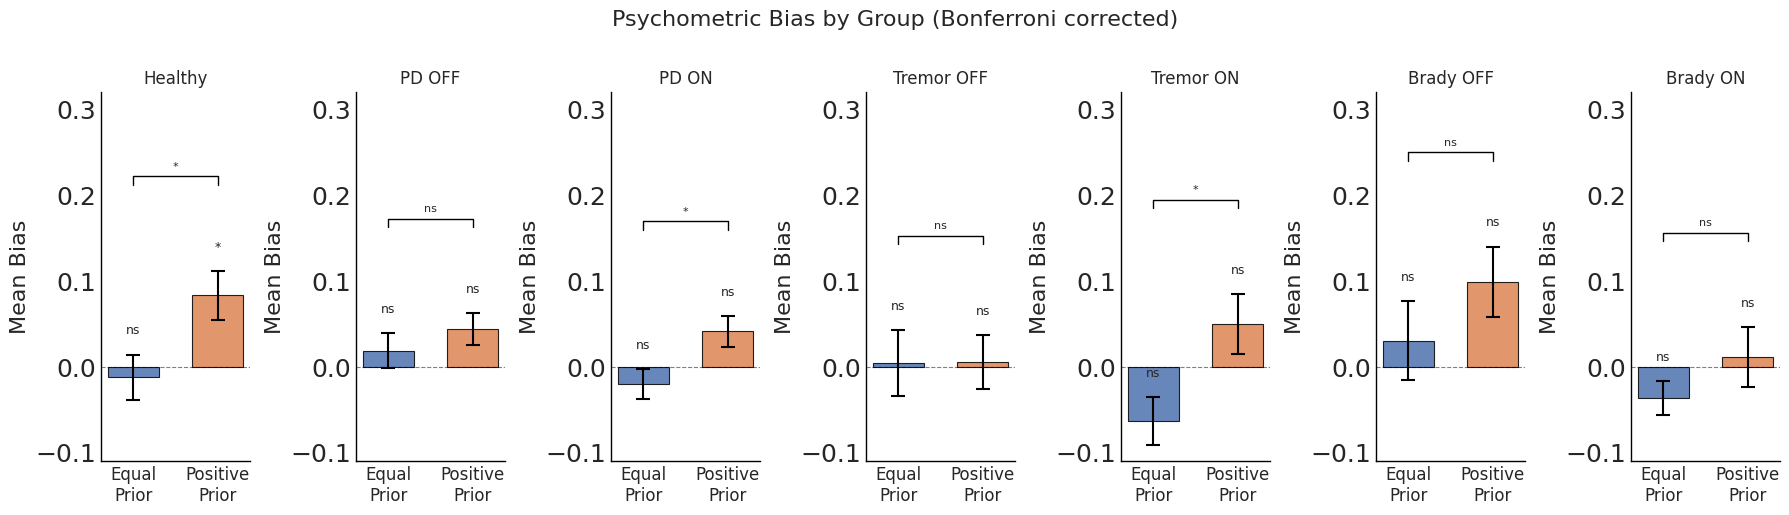

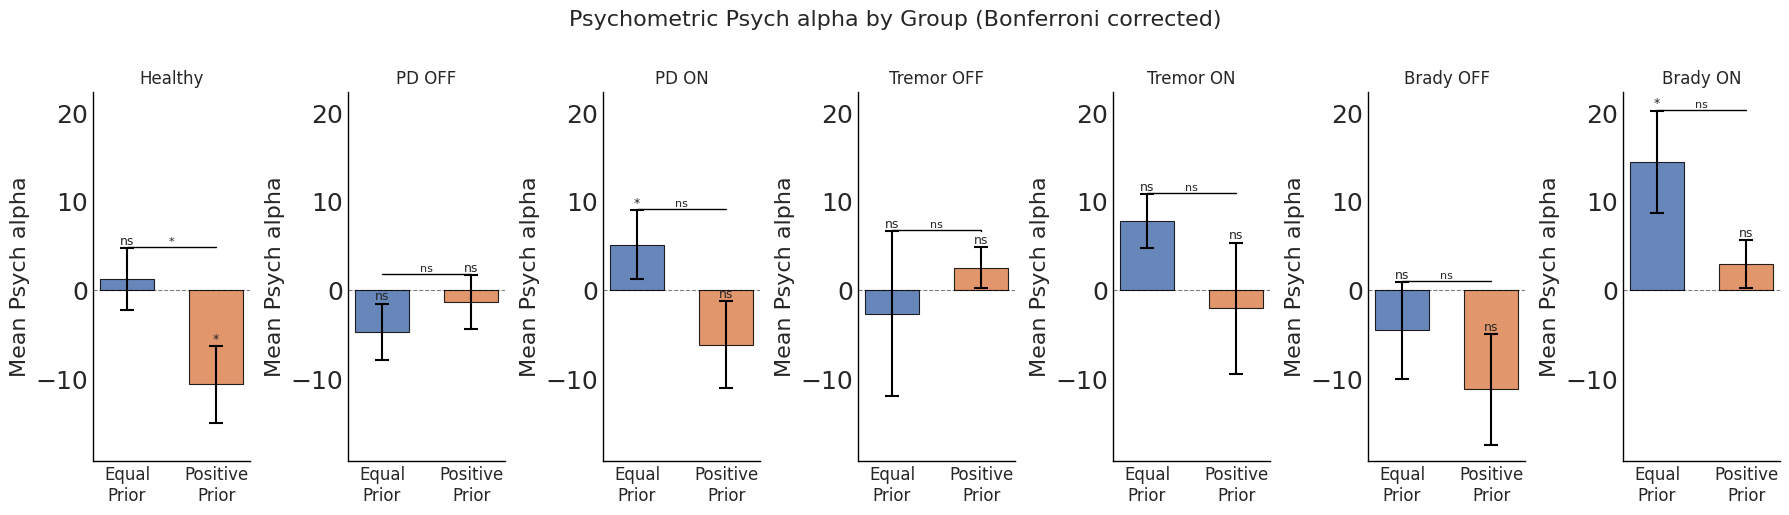

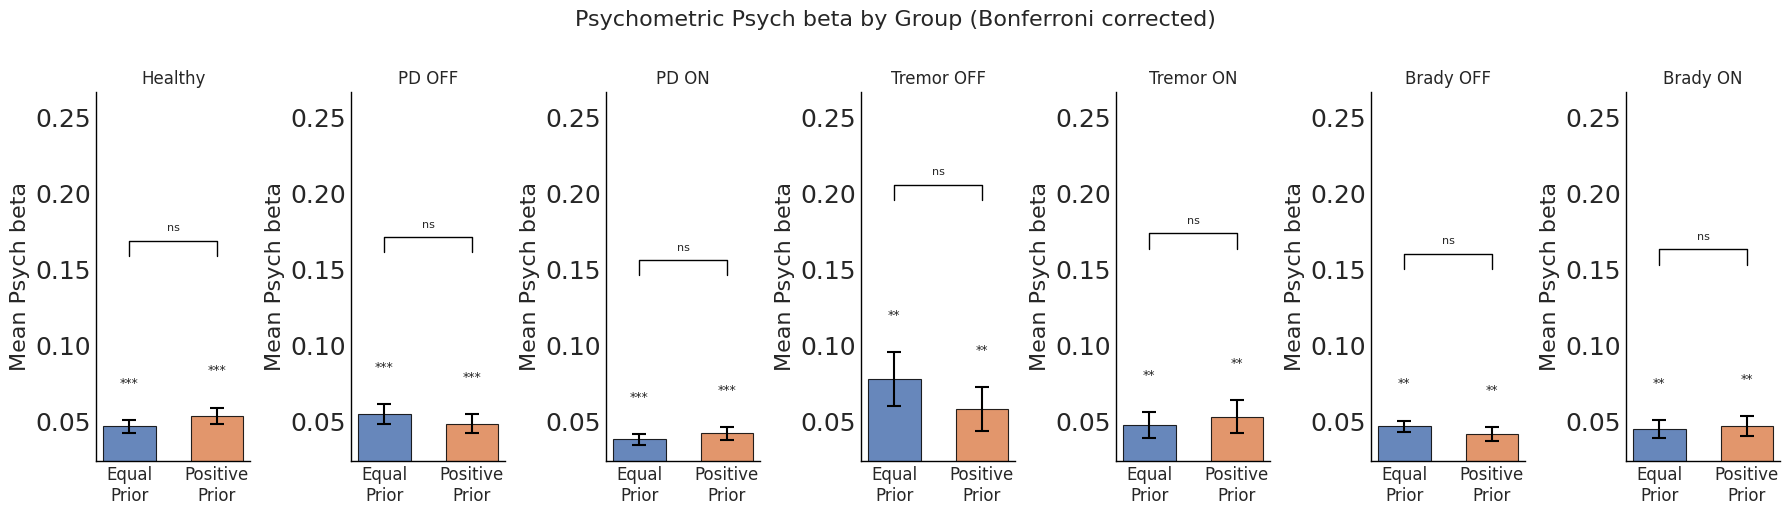

In [17]:
from src.utils.stats_utils import wilcoxon_battery
from src.utils.plotting import add_significance_bracket
from scipy import stats as scipy_stats

test_labels  = ["equal", "positive"]
test_xlabels = ["Equal\nPrior", "Positive\nPrior"]
bar_colors   = ["#4C72B0", "#DD8452"]
bar_x        = np.array([0, 1])

group_order  = ["healthy", "pd_off", "pd_on", "tremor_off", "tremor_on", "brady_off", "brady_on"]
group_titles = {
    "healthy":    "Healthy",
    "pd_off":     "PD OFF",
    "pd_on":      "PD ON",
    "tremor_off": "Tremor OFF",
    "tremor_on":  "Tremor ON",
    "brady_off":  "Brady OFF",
    "brady_on":   "Brady ON",
}


for var in ["bias", "psych_alpha", "psych_beta"]:
    fig, axes = plt.subplots(1, len(group_order), figsize=(18, 5))
    y_min, y_max = np.inf, -np.inf
    for ax, grp in zip(axes, group_order):
        group_data   = psych_params.loc[grp_indices[grp]]
        pos_centered = group_data[f"positive_{var}"] if var != "bias" else group_data[f"positive_{var}"] - 0.5
        eq_centered  = group_data[f"equal_{var}"] if var != "bias" else group_data[f"equal_{var}"] - 0.5

        results = wilcoxon_battery(
            tests={
                "equal":      (eq_centered,),
                "positive":   (pos_centered,),
                "positive_vs_equal": (group_data[f"positive_{var}"], group_data[f"equal_{var}"]),
            },
            print_results=False,
        ).set_index("test")

        diffs = {
            "equal":    eq_centered,
            "positive": pos_centered,
        }

        bar_tops = {}
        for xi, (test_name, color) in enumerate(zip(test_labels, bar_colors)):
            vals = diffs[test_name].values
            mean = np.mean(vals)
            sem  = scipy_stats.sem(vals)

            ax.bar(xi, mean, color=color, edgecolor="k", linewidth=0.8, width=0.6, alpha=0.85)
            ax.errorbar(xi, mean, yerr=sem, fmt="none", color="k",
                        capsize=5, elinewidth=1.5, capthick=1.5)

            corr_p = results.loc[test_name, "corrected_p"]
            star   = "***" if corr_p < 0.001 else "**" if corr_p < 0.01 else "*" if corr_p < 0.05 else "ns"
            ax.text(xi, mean + sem + 0.02, star, ha="center", va="bottom", fontsize=9)

            bar_tops[test_name] = mean + sem
            y_min = min(y_min, mean - sem)
            y_max = max(y_max, mean + sem + 0.08)

        bracket_y = max(bar_tops.values()) + 0.10
        p_vs_eq   = results.loc["positive_vs_equal", "corrected_p"]
        p_str = "***" if p_vs_eq < 0.001 else "**" if p_vs_eq < 0.01 else "*" if p_vs_eq < 0.05 else "ns# p < 0.001" if p_vs_eq < 0.001 else "ns" #f"p = {p_vs_eq:.3f}"
        ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + 0.01, bracket_y + 0.01, bracket_y], color="k", lw=1)
        ax.text(0.5, bracket_y + 0.015, p_str, ha="center", va="bottom", fontsize=8)

        y_max = max(y_max, bracket_y + 0.06)

        ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
        ax.set_xticks(bar_x)
        ax.set_xticklabels(test_xlabels, fontsize=12)
        ax.set_title(group_titles[grp],fontsize=12)
        ax.set_ylabel(f"Mean {var.capitalize().replace('_', ' ')}")
        ax.grid(False)
        # for sp in ["top", "right"]:
        #     ax.spines[sp].set_visible(False)
        # for sp in ["left", "bottom"]:
        #     ax.spines[sp].set_visible(True)
        #     # ax.spines[sp].set_linewidth(1)

    pad = (y_max - y_min) * 0.05
    for ax in axes:
        ax.set_ylim(y_min - pad, y_max + pad)

    plt.suptitle(f"Psychometric {var.capitalize().replace('_', ' ')} by Group (Bonferroni corrected)", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()


### Comparison between tremor_off and brady_off

In [51]:
from scipy.stats import mannwhitneyu
import numpy as np

# Average slope across both prior conditions per subject, then compare groups
trem_data  = psych_params.loc[grp_indices['tremor_off']]
brady_data = psych_params.loc[grp_indices['brady_off']]

trem_beta  = (trem_data["equal_psych_beta"]  + trem_data["positive_psych_beta"])  / 2
brady_beta = (brady_data["equal_psych_beta"] + brady_data["positive_psych_beta"]) / 2

stat, p = mannwhitneyu(trem_beta, brady_beta, alternative='two-sided')

print(f"Psychometric slope (beta) — Tremor OFF vs Brady OFF — Mann-Whitney U")
print(f"  Tremor OFF (n={len(trem_beta)}):  mean beta = {trem_beta.mean():.4f} ± {trem_beta.std():.4f}")
print(f"  Brady OFF  (n={len(brady_beta)}): mean beta = {brady_beta.mean():.4f} ± {brady_beta.std():.4f}")
print(f"  U = {stat:.1f}, p = {p:.3f}")


Psychometric slope (beta) — Tremor OFF vs Brady OFF — Mann-Whitney U
  Tremor OFF (n=11):  mean beta = 0.0677 ± 0.0513
  Brady OFF  (n=10): mean beta = 0.0440 ± 0.0113
  U = 59.0, p = 0.805


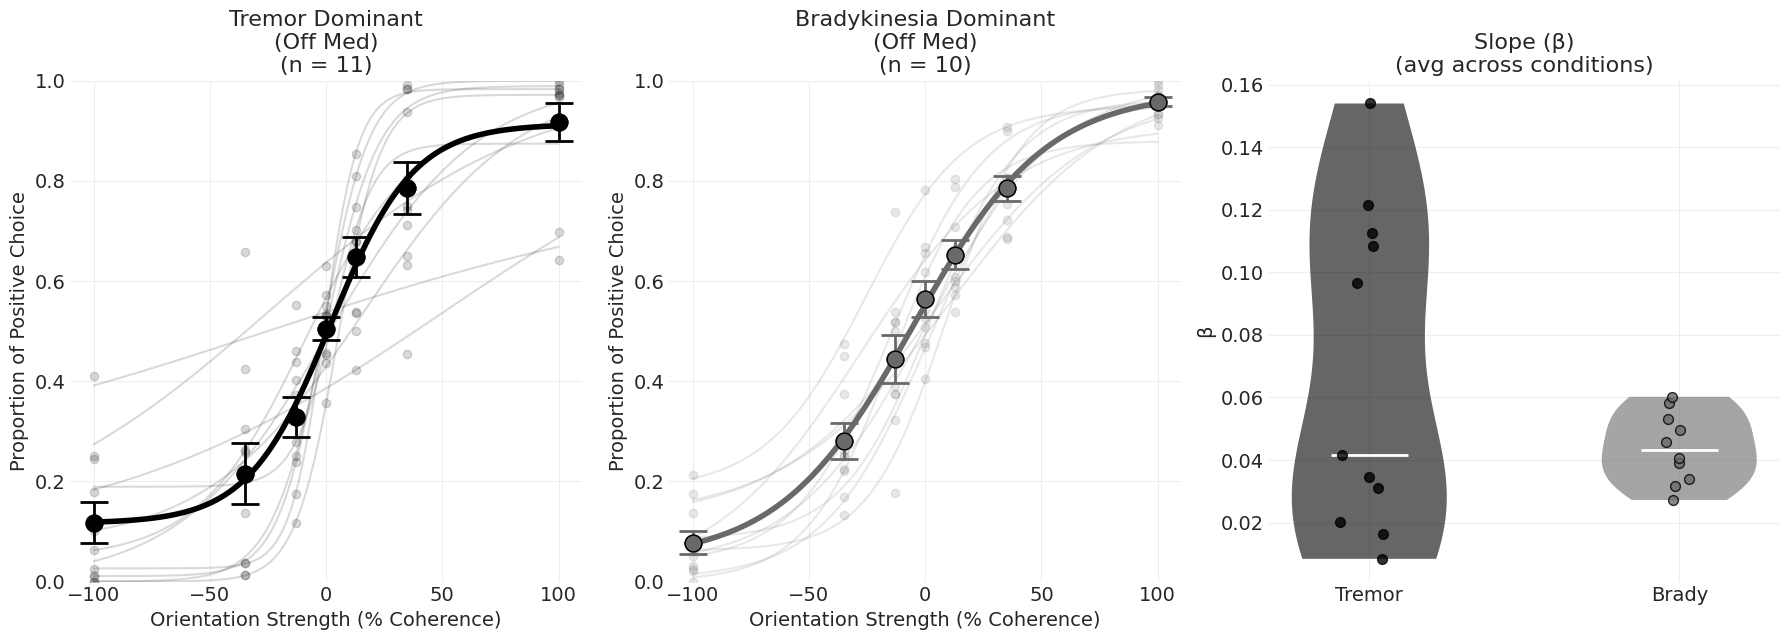

In [52]:
from scipy import stats as scipy_stats

def get_combined_psych(data):
    """Average psychometric data across both prior conditions, return data + fitted curve."""
    results = {}
    for key, color_val in [('pos', 1), ('eq', 0)]:
        coh, psych, _, x_hat, _ = pmf_utils.get_psychometric_data(data[data['color'] == color_val])
        results[key] = {'coh': coh, 'psych': psych, 'x_hat': x_hat}
    coh        = results['pos']['coh']
    mean_psych = (results['pos']['psych'] + results['eq']['psych']) / 2
    x_hat      = results['pos']['x_hat']
    fit = pmf_utils.fit_psychometric_function(coh, mean_psych, trial_counts=None, model_type='logit_4')
    return coh, mean_psych, x_hat, fit.predict(x_hat)

fig, axes = plt.subplots(1, 3, figsize=(18, 6.5))
err_style = {'elinewidth': 2, 'capsize': 10, 'capthick': 2}

group_cfg = [
    ('Tremor Dominant\n(Off Med)',       'tremor_off',  'black'),
    ('Bradykinesia Dominant\n(Off Med)', 'brady_off',   'dimgray'),
]

for ax, (title, grp_key, color) in zip(axes[:2], group_cfg):
    session_ids = processed_metadata.loc[grp_indices[grp_key], 'session_id']
    coh_list, psych_list, x_hat_list = [], [], []

    for sid in session_ids:
        session_data = filtered_data[filtered_data['session_id'] == sid]
        if len(session_data) == 0:
            continue
        coh, psych, x_hat, y_hat = get_combined_psych(session_data)
        coh_list.append(coh)
        psych_list.append(psych)
        x_hat_list.append(x_hat)
        ax.plot(coh, psych, color=color, marker='o', ls='', alpha=0.15)
        ax.plot(x_hat, y_hat, color=color, ls='-', lw=1.5, alpha=0.15)

    coh_arr   = np.array(coh_list)
    psych_arr = np.array(psych_list)
    mean_coh   = np.mean(coh_arr, axis=0)
    mean_psych = np.mean(psych_arr, axis=0)
    mean_x_hat = np.mean(np.array(x_hat_list), axis=0)

    ax.plot(mean_coh, mean_psych, color=color, ls='', marker='o', ms=12, mec='k')
    ax.errorbar(mean_coh, mean_psych, yerr=scipy_stats.sem(psych_arr, axis=0),
                color=color, ls='', marker='o', ms=12, mec='k', **err_style)
    fit = pmf_utils.fit_psychometric_function(mean_coh, mean_psych, trial_counts=None, model_type='logit_4')
    ax.plot(mean_x_hat, fit.predict(mean_x_hat), color=color, ls='-', lw=4)
    ax.set(xlabel='Orientation Strength (% Coherence)', ylabel='Proportion of Positive Choice',
           ylim=(0, 1), title=f"{title}\n(n = {len(psych_list)})")
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)

# Violin plot for slope comparison
beta_ax = axes[2]
trem_beta  = (psych_params.loc[grp_indices['tremor_off'], 'equal_psych_beta'] +
              psych_params.loc[grp_indices['tremor_off'], 'positive_psych_beta']) / 2
brady_beta = (psych_params.loc[grp_indices['brady_off'],  'equal_psych_beta'] +
              psych_params.loc[grp_indices['brady_off'],  'positive_psych_beta']) / 2

parts = beta_ax.violinplot([trem_beta.values, brady_beta.values], positions=[0, 1],
                            showmedians=True, showextrema=False)
for pc, color in zip(parts['bodies'], ['black', 'dimgray']):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
parts['cmedians'].set_color('white')
parts['cmedians'].set_linewidth(2)

for xi, vals, color in [(0, trem_beta.values, 'black'), (1, brady_beta.values, 'dimgray')]:
    beta_ax.scatter(np.random.normal(xi, 0.04, size=len(vals)), vals,
                    color=color, edgecolor='k', s=50, zorder=3, alpha=0.8)

beta_ax.set_xticks([0, 1])
beta_ax.set_xticklabels(['Tremor', 'Brady'])
beta_ax.set(title='Slope (β)\n(avg across conditions)', ylabel='β')
for sp in ['top', 'right']:
    beta_ax.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()


# DDM Params

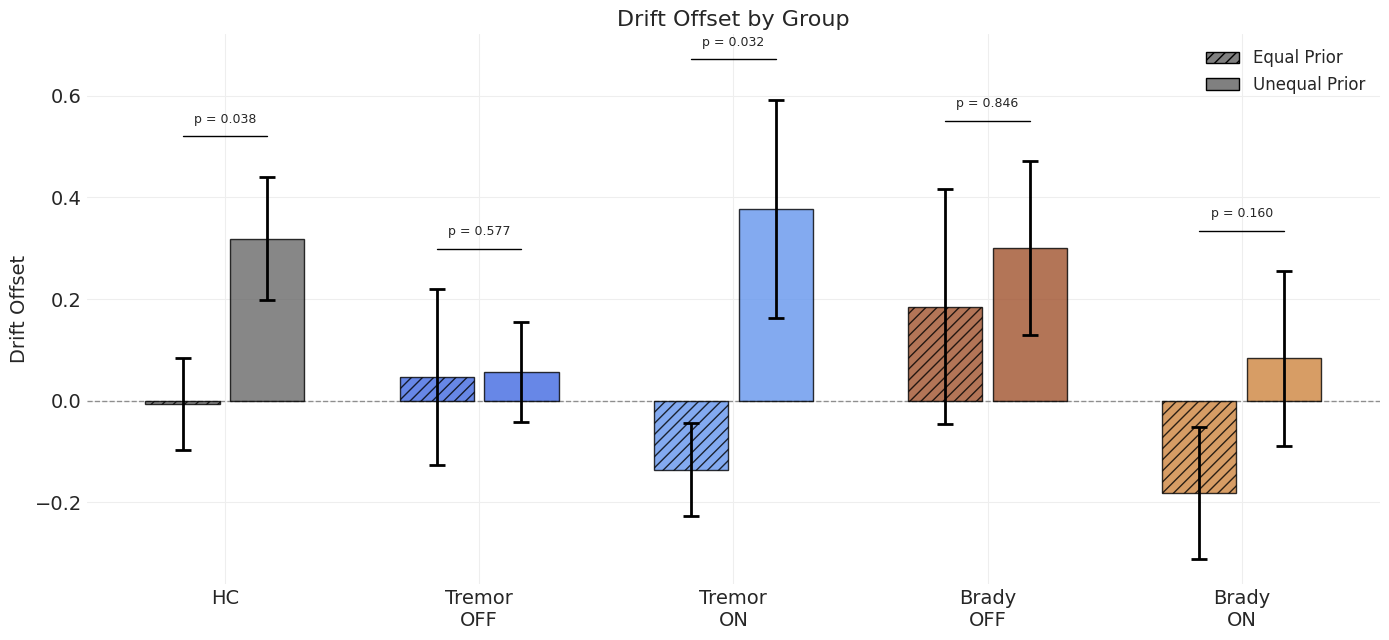

In [53]:
from scipy import stats as scipy_stats
from scipy.stats import wilcoxon
from matplotlib.patches import Patch
import numpy as np

group_cfg = [
    ('HC',          'healthy',    'dimgray'),
    ('Tremor\nOFF', 'tremor_off', 'royalblue'),
    ('Tremor\nON',  'tremor_on',  'cornflowerblue'),
    ('Brady\nOFF',  'brady_off',  'sienna'),
    ('Brady\nON',   'brady_on',   'peru'),
]

cond_cfg = [
    ('Equal Prior',   'drift_offset_prior_cond_0', -0.2, '///'),
    ('Unequal Prior', 'drift_offset_prior_cond_1',  0.2, ''),
]

fig, ax = plt.subplots(figsize=(14, 6.5))
xtick_pos, xtick_labels = [], []

for gi, (label, grp_key, color) in enumerate(group_cfg):
    idx  = grp_indices[grp_key]
    xpos = gi * 1.2
    xtick_pos.append(xpos)
    xtick_labels.append(label)

    vals_by_cond = {}
    for cond_label, col, offset, hatch in cond_cfg:
        vals = processed_metadata.loc[idx, col].dropna().values
        vals_by_cond[col] = vals
        pos  = xpos + offset

        ax.bar(pos, np.mean(vals), width=0.35, color=color, edgecolor='k',
               hatch=hatch, alpha=0.8)
        ax.errorbar(pos, np.mean(vals), yerr=scipy_stats.sem(vals),
                    fmt='none', color='k', capsize=6, elinewidth=2, capthick=2)

    # Wilcoxon signed-rank: equal vs unequal prior within group
    eq_vals   = vals_by_cond['drift_offset_prior_cond_0']
    uneq_vals = vals_by_cond['drift_offset_prior_cond_1']
    n = min(len(eq_vals), len(uneq_vals))
    _, p = wilcoxon(eq_vals[:n], uneq_vals[:n])
    p_str = f'p = {p:.3f}' if p >= 0.001 else 'p < 0.001'

    y_top = max(np.mean(eq_vals) + scipy_stats.sem(eq_vals),
                np.mean(uneq_vals) + scipy_stats.sem(uneq_vals)) + 0.08
    ax.plot([xpos - 0.2, xpos + 0.2], [y_top, y_top], color='k', lw=1)
    ax.text(xpos, y_top + 0.02, p_str, ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='k', lw=1, ls='--', alpha=0.4)
ax.set_xticks(xtick_pos)
ax.set_xticklabels(xtick_labels)
ax.set(ylabel='Drift Offset', title='Drift Offset by Group')
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)

legend_elements = [
    Patch(facecolor='gray', edgecolor='k', hatch='///', label='Equal Prior'),
    Patch(facecolor='gray', edgecolor='k', label='Unequal Prior'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False)

plt.tight_layout()
plt.show()
